# **Week3 복습과제**



이번 복습과제에서는 두 가지 레이어에 대한 내용을 다룹니다. `ReLU 활성화 함수와 조합된 convolution layer`와 `maximum pooling layer`입니다.
각각에 대해 알아보고 사진에 적용하는 실습을 해보겠습니다.

Convolution layer, ReLU 활성화 함수, 그리고 maximum pooling layer는 특성 추출 과정에서 각각 다음과 같은 역할을 합니다.
- 이미지를 특정 특징에 맞게 필터링  ->  Convolution Layer
- 필터링된 이미지에서 해당 특징을 감지  ->  ReLU Activation Function
- 특징을 강조하기 위해 이미지를 압축  ->  Maximum Pooling Layer

아래 이미지에서는 이 세 가지 연산이 원본 이미지의 가로 선 특징을 추출해낸 것을 볼 수 있습니다.
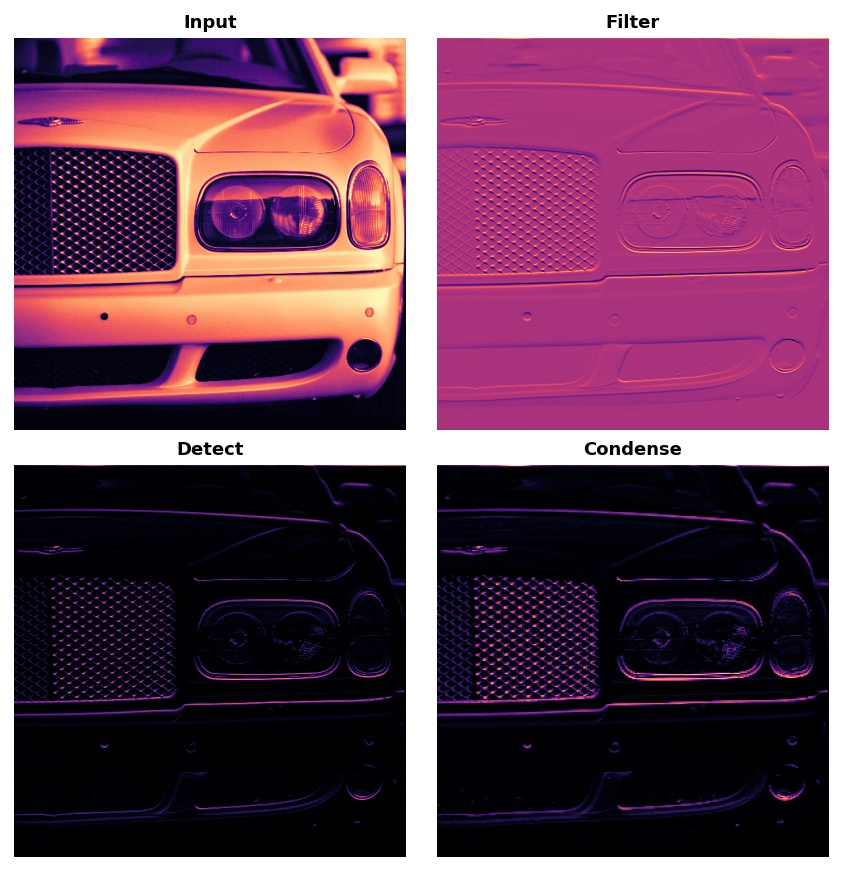



<a id="1"></a> <br>
## 1. Convolution Layer

- Convolution layer는 keras 모델에서 아래의 코드와 같이 정의할 수 있습니다.

 - keras 모델은 keras 라이브러리를 사용하여 구축된 딥러닝 모델을 말합니다.
 - 복잡한 신경망 모델을 간단한 코드로 만들 수 있게 도와줍니다.
   - `Conv2D` layer를 설정해주세요.




In [2]:
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
model = keras.Sequential([
    layers.Conv2D(filters=64, kernel_size=3, activation = None, input_shape=(28, 28, 1)) # 활성화층 x -> 선형 계산만 수행
    # 더 많은 레이어가 추가될 수 있습니다.
    # 은닉층, 추가 컨볼루션층, 출력층 등.
])

/opt/anaconda3/envs/euron/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-03-29 15:45:08.154489: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2025-03-29 15:45:08.154541: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-03-29 15:45:08.154550: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-03-29 15:45:08.154599: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-03-29 15:45:08.154615: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:

<a id="1"></a> <br>
## 2. ReLU Activation Function

- 위의 convolution layer에 ReLU를 적용시켜봅시다.

In [4]:
model = keras.Sequential([
    layers.Conv2D(filters=64, kernel_size=3, activation='relu') # 활성화 함수로 ReLU가 선택된 것을 볼 수 있음.
    # 더 많은 레이어가 추가될 수 있습니다.
])

<a id="1"></a> <br>
## 3. Maximum Pooling Layer

- 앞서 구축한 keras 모델에 maximum pooling layer를 추가해봅시다.
 - keras에서는 `MaxPool2D` layer가 사용됩니다.

In [5]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Conv2D(filters=64, kernel_size=3, activation = 'relu'),
    layers.MaxPool2D(pool_size=2)
    # 더 많은 레이어가 추가될 수 있습니다.
])

<a id="1"></a> <br>
## 4. 예제

- 예제에서는 Convolution layer가 안 보이는 곳에서 수행하는 작업을 더 잘 이해하기 위해 직접 특징 추출 과정을 진행해보겠습니다.
 - 첨부된 이미지 파일을 준비해주세요.

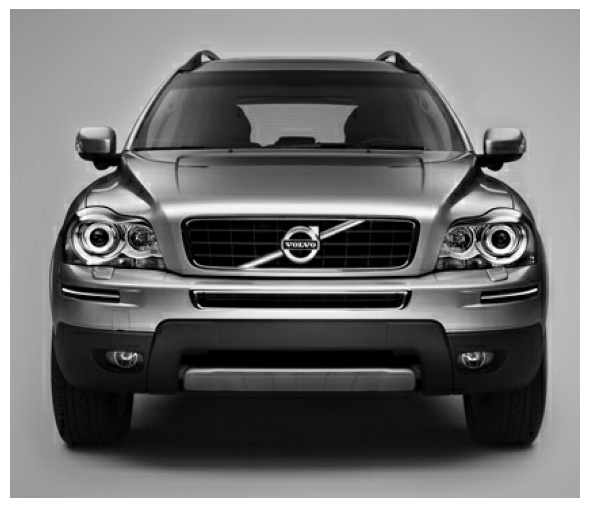

In [6]:
# 이 셀을 실행시켜주세요!
import tensorflow as tf
import matplotlib.pyplot as plt
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')

image_path = './car_feature.jpg'  #첨부된 이미지 파일을 사용해주세요
image = tf.io.read_file(image_path) # 이미지 파일을 읽고 
image = tf.io.decode_jpeg(image) # JPEG로 decoding하여 image가 TensorFlow 형태가 됨

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image), cmap='gray') # 차원 중 1인 차원 제거 
plt.axis('off')
plt.show();

In [7]:
# 이 셀을 실행해주세요!
import numpy as np
from itertools import product

def show_kernel(kernel, label=True, digits=None, text_size=28): # 합성곱 필터를 시각화함
    # Format kernel # kernel: 2D array
    kernel = np.array(kernel) # list/numpy -> numpy 형태로 변형 
    if digits is not None: # digits을 사용자가 설정했다면 
        kernel = kernel.round(digits) # 그 값을 기준으로 kernel 반올림

    # Plot kernel
    cmap = plt.get_cmap('Blues_r')
    plt.imshow(kernel, cmap=cmap)
    rows, cols = kernel.shape
    thresh = (kernel.max() + kernel.min())/2
    # Optionally, add value labels
    if label:
        for i, j in product(range(rows), range(cols)): # product: 이중 for문을 한 줄에 나타냄
            val = kernel[i, j]
            color = cmap(0) if val > thresh else cmap(255)
            plt.text(j, i, val,
                     color=color, size=text_size,
                     horizontalalignment='center', verticalalignment='center')
    plt.xticks([])
    plt.yticks([])

#### **Kernel로 필터링**
- 필터링 단계에서는 kernel을 직접 정의한 후 convolution을 사용하여 적용하겠습니다.
- 이렇게 하면 TensorFlow에서 사용하는 **텐서(tensor)** 형태로 커널이 생성됩니다.

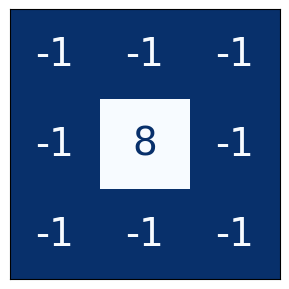

In [8]:
import tensorflow as tf

kernel = tf.constant([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1],
])

plt.figure(figsize=(3, 3))
show_kernel(kernel)

In [9]:
# 이 셀을 실행해주세요!
image = tf.image.convert_image_dtype(image, dtype=tf.float32)
image = tf.expand_dims(image, axis=0) # 배치 차원 추가, [batch, height, width, channels]
kernel = tf.reshape(kernel, [*kernel.shape, 1, 1]) #  [kernel_height, kernel_width, in_channels, out_channels]
kernel = tf.cast(kernel, dtype=tf.float32)

- 이제 커널을 이미지에 적용시켜봅시다.
 - `input=image`
 - `filters=kernel`

In [10]:
print(image.shape)
print(kernel.shape)

(1, 361, 421, 1)
(3, 3, 1, 1)


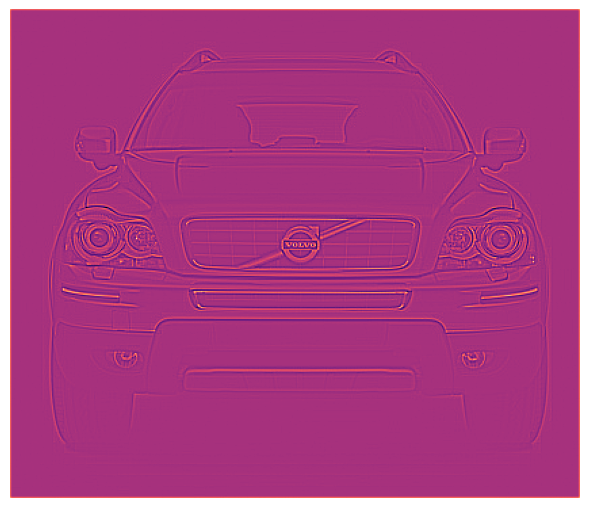

In [11]:
image_filter = tf.nn.conv2d(
    input = image, 
    filters = kernel,
    strides=1,
    padding='SAME' # 출력크기와 입력 크기를 같게 유지
)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_filter))
plt.axis('off')
plt.show();

**해당 셀의 마크 다운을 풀고 우리가 생성한 커널이 이미지의 어떤 특성을 추출했는지 해석해주세요.** 🤗



---
**[해석]**
-   생성한 커널은 라플라시안 커널(Laplacian Kernel)로 이미지를 분석할 때 엣지를 강조할 때 사용하는 커널로, 중심 픽셀 값에서 주변 8개의 값을 모두 빼서 변화량을 계산하는 구조이다.
-   주변과 큰 차이가 있는 경계선(엣지)에서 값이 커지고 변화가 없는 부분에서 0이 된다. 
-   즉, 이 커널을 사용해 image의 경계 부분을 (주변과 값의 크기가 많이 나는 부분) 추출했다. 


#### **ReLU로 특성 감지**
- 다음으로, ReLU 함수로 특성을 감지하게끔 하겠습니다.

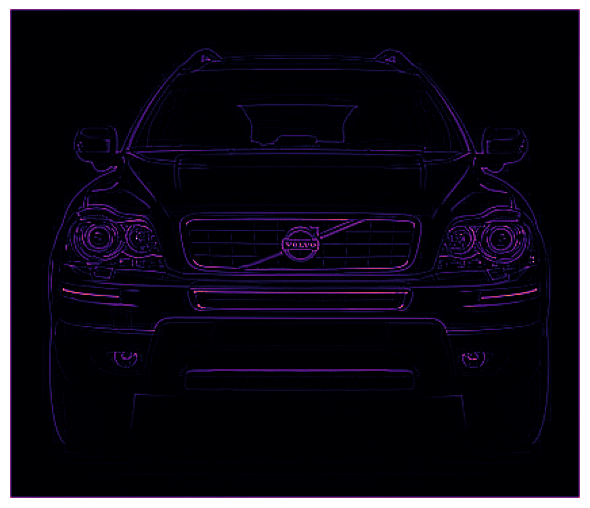

In [12]:
image_detect = tf.nn.relu(image_filter)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_detect))
plt.axis('off')
plt.show();

* 처음 사용한 라플라시안 커널은 양방향으로 엣지를 검출했기 때문에 결과값에 양수와 음수가 섞여 있음
* max(0, x)를 반환하는 ReLU 함수를 사용해 양수값만 검출해서 엣지의 유무만 확인함

In [13]:
image_detect.shape

TensorShape([1, 361, 421, 1])

#### **Maximum Pooling으로 압축**
- 이제 마지막으로 풀링 단계를 적용해보겠습니다.
 - tf.nn의 또 다른 함수인 tf.nn.pool을 사용하겠습니다.
 - 이 함수는 모델을 만들 때 사용하는 MaxPool2D 레이어와 동일한 역할을 하지만, 단순한 Python 함수이므로 직접 사용하기에 더 편리합니다.
 - 이 함수에서는 window_shape가 pooling 크기를 나타냅니다!
   - `input = image_detect`
   - `window_shape=(2, 2)`
   - `pooling_type='MAX'`


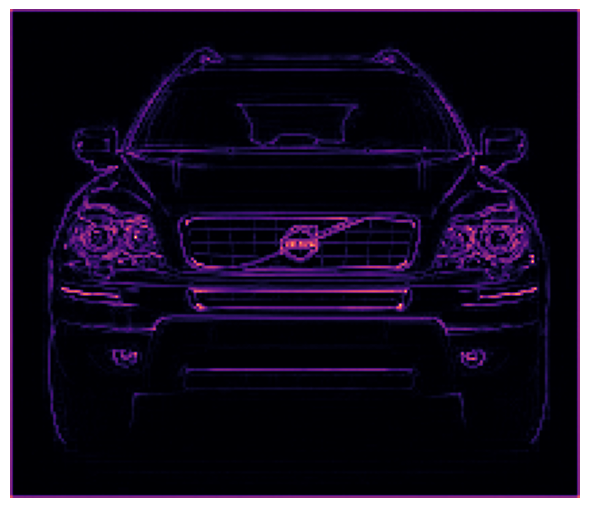

In [14]:
import tensorflow as tf

image_condense = tf.nn.pool(
    input= image_detect, # ReLU가 적용된 이미지
    window_shape= (2, 2), # 2x2 크기의 창(window)을 슬라이딩하면서
    pooling_type= 'MAX', # maximum pooling을 사용해서 각 영역의 최댓값만 남김 -> 이미지에서 중요한 특성만 더 압축해서 보존
    strides=(2, 2), 
    padding='SAME',
)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_condense))
plt.axis('off')
plt.show();

<a id="1"></a> <br>
## 5. 직접 이미지 특성 추출해보기!

1️⃣ **실험 1: 직접 이미지의 특성 추출하기**
- 예제의 과정을 본인이 원하는 커널을 만들어 진행해주세요.
 - 새로운 임의의 커널 `my_kernel`을 생성한 뒤 출력해주세요.
 - 커널을 이미지에 적용한 뒤 출력해주세요.
 - ReLU 함수를 사용해주세요.
 - Maximum pooling을 진행해주세요.
- 마지막 셀의 마크다운을 풀고, 본인이 수행한 작업이 이미지의 어떤 특성을 추출했는지 설명해주세요.

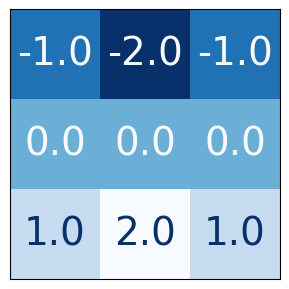

In [15]:
my_kernel = tf.constant([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=tf.float32)

plt.figure(figsize=(3, 3))
show_kernel(my_kernel)

In [16]:
my_kernel = tf.reshape(my_kernel, [*my_kernel.shape, 1, 1]) #  [kernel_height, kernel_width, in_channels, out_channels]
my_kernel = tf.cast(my_kernel, dtype=tf.float32)

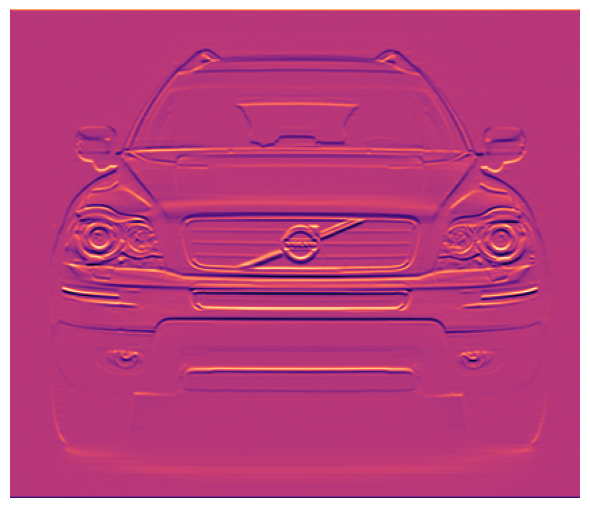

In [17]:
image_filter = tf.nn.conv2d(
    input = image, 
    filters = my_kernel,
    strides=1,
    padding='SAME' # 출력크기와 입력 크기를 같게 유지
)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_filter))
plt.axis('off')
plt.show();

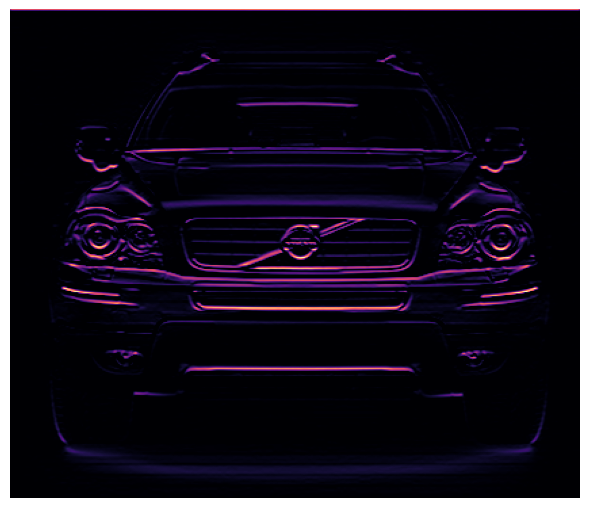

In [18]:
image_detect = tf.nn.relu(image_filter)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_detect))
plt.axis('off')
plt.show();


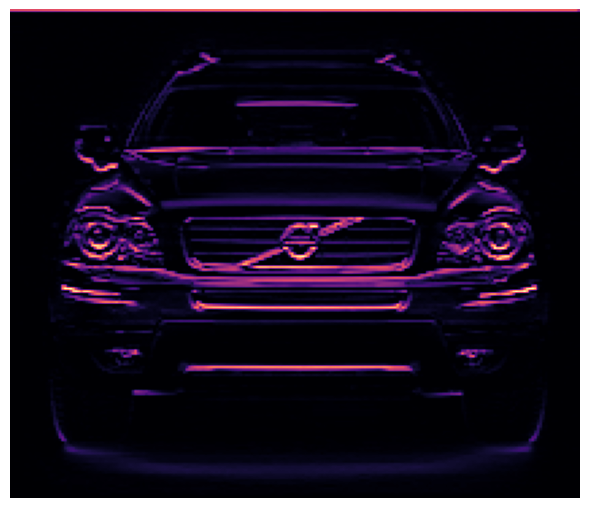

In [19]:
image_condense = tf.nn.pool(
    input= image_detect, # ReLU가 적용된 이미지
    window_shape= (2, 2), # 2x2 크기의 창(window)을 슬라이딩하면서
    pooling_type= 'MAX', # maximum pooling을 사용해서 각 영역의 최댓값만 남김 -> 이미지에서 중요한 특성만 더 압축해서 보존
    strides=(2, 2), 
    padding='SAME',
)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_condense))
plt.axis('off')
plt.show();

**해당 셀의 마크 다운을 풀고 예제 코드와 어떤 점을 다르게 변형했고 이미지의 어떤 특성을 추출했는지 해석해주세요.**



---
**[차이점]**
-   새로 만든 커널은 수평 방향의 경계만 감지하도록, 커널의 위쪽은 -, 가운데는 0, 아래쪽은 + 부호가 되도록 조절하였다. 이로써, 위아래의 밝기 변화가 클 때의 엣지가 강조되도록 하였다. 

**[해석]**
-   가로 엣지가 많은 자동차의 모습이 잘 드러나있다. 하지만, 전 방향의 밝기를 비교했던 첫 번째 커널과 달리, 세로 방향의 경계는 잘 감지하지 못하는 모습을 보인다. 


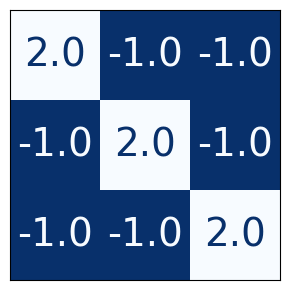

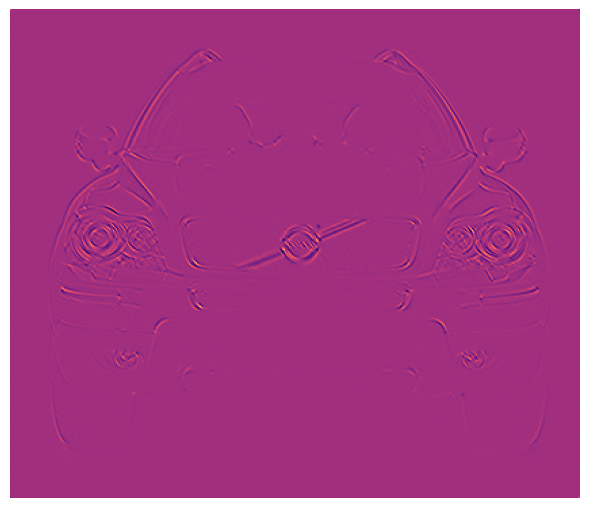

In [26]:
my_kernel = tf.constant([
    [2, -1, -1],
    [ -1,  2,  -1],
    [ -1,  -1,  2]
], dtype=tf.float32)

plt.figure(figsize=(3, 3))
show_kernel(my_kernel)

my_kernel = tf.reshape(my_kernel, [*my_kernel.shape, 1, 1]) #  [kernel_height, kernel_width, in_channels, out_channels]
my_kernel = tf.cast(my_kernel, dtype=tf.float32)

image_filter = tf.nn.conv2d(
    input = image, 
    filters = my_kernel,
    strides=1,
    padding='SAME' # 출력크기와 입력 크기를 같게 유지
)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_filter))
plt.axis('off')
plt.show();

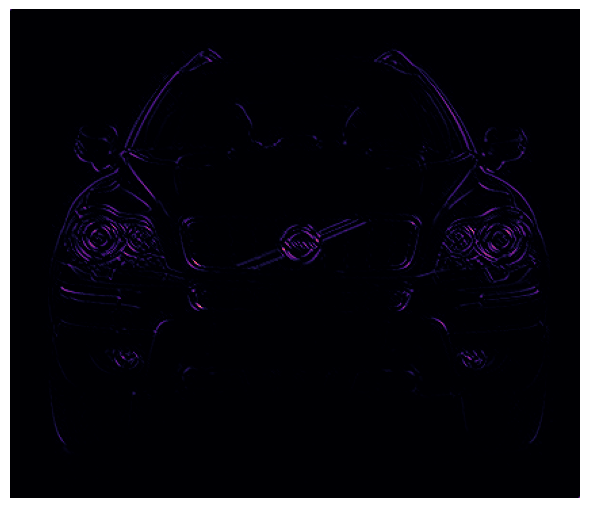

In [27]:
image_detect = tf.nn.relu(image_filter)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_detect))
plt.axis('off')
plt.show();


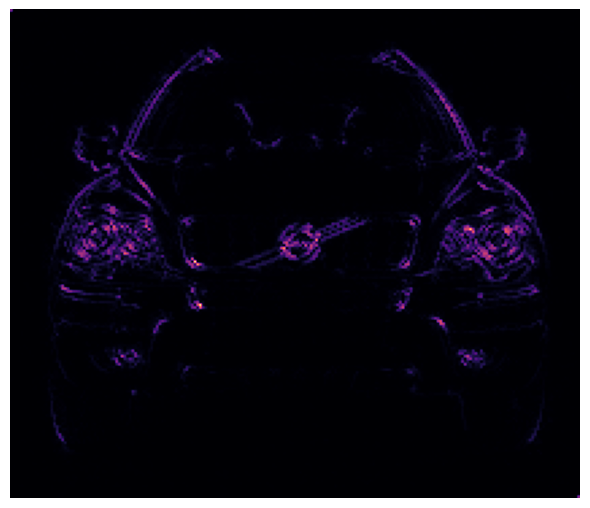

In [28]:
image_condense = tf.nn.pool(
    input= image_detect, # ReLU가 적용된 이미지
    window_shape= (2, 2), # 2x2 크기의 창(window)을 슬라이딩하면서
    pooling_type= 'MAX', # maximum pooling을 사용해서 각 영역의 최댓값만 남김 -> 이미지에서 중요한 특성만 더 압축해서 보존
    strides=(2, 2), 
    padding='SAME',
)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_condense))
plt.axis('off')
plt.show();